## Configuration

In [39]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from functools import partial


from lordcapulet.data_structures.databank import DataBank
from botorch.acquisition import UpperConfidenceBound
from botorch.acquisition.objective import ScalarizedPosteriorTransform

from gp_model import create_gp_model, train_gp_model
from acquisition import AnalyticCustomPreference, compute_total_preference_fast
from optimizer import optimize_acquisition, create_bounds_tensor, create_patchwork_guess

# =============================================================================
# CONFIGURATION
# =============================================================================

CONFIG = {
    # Device
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    
    # Data
    # "data_file": "FeO_scan_data_extractor_redone.json",
    "data_file": "UO2_scan_data_extractor_so_n_converted.json",
    "train_ratio": 0.5,  # Fraction of data for training
    
    # Physics Mean Function
    "mean": {
        "type": "VectorizedPhysicsMean",
        # "type": "HubbardUMean",
        "J_prior": {"mean": 0.5, "std": 0.1},
        "U_prior": {"mean": 5.0, "std": 0.2},
    },
    
    # Kernel Configuration
    "kernel": {
        "local": {
            # "matern": {"enabled": True, "nu": 2.5, "outputscale_prior": {"mean": 2, "std": 0.2}},
            "matern": {"enabled": True, "nu": 2.5, "outputscale_prior": {"mean": 0.2, "std": 0.02}},
            # "matern": {"enabled": True, "nu": 2.5, "outputscale_prior": {"mean": 0.002, "std": 0.0000002}},
        },
        "nonlocal": {
            "residual": {"enabled": False, "outputscale_prior": {"mean": 0.05, "std": 0.003}},
        },
        "spin_flip_invariant": True,
    },
    
    # Acquisition Function
    "acquisition": {
        "beta": 1,  # Exploration parameter (0=pure exploitation)
        "use_preference": True,
        "trace_target": 2.7,  # Target electron count
        # "trace_target": 6.3,  # Target electron count
        "trace_sigma": 0.5,  # Increased to allow more variation 
        # "trace_sigma": 1.0,  # Increased to allow more variation
        "use_eigenvalue_preference": True,  # Eigenvalue constraints
        "eigenvalue_k": 20000.0,
        "supergaussian_index": 4,  # Super-Gaussian index for trace preference
    },
    
    # Optimization
    "optimization": {
        "num_candidates": 10,
        "init_strategy": "patchwork",  # "best_train", "patchwork", or None
        "apply_rotation": False,  # Apply random rotations to patchwork guess
        "num_restarts": 40,
        "raw_samples": 128,
    },
}


DEVICE = torch.device(CONFIG["device"])
print(f"Device: {DEVICE}")
print(f"Data: {CONFIG['data_file']}")
print(f"Candidates to generate: {CONFIG['optimization']['num_candidates']}")

Device: cuda
Data: UO2_scan_data_extractor_so_n_converted.json
Candidates to generate: 10


## Data Loading

In [40]:
# Load data
databank = DataBank.from_json(CONFIG["data_file"], only_converged=True)
atoms = databank.atom_ids

# Prepare tensors
x_data = databank.to_pytorch(atom_ids=atoms, spins=['up', 'down'], include_energies=False, device=DEVICE)
energies = torch.tensor([rec['energy'] for rec in databank._records], dtype=torch.float32, device=DEVICE)

# Train/test split
num_train = int(len(x_data) * CONFIG["train_ratio"])
perm = torch.randperm(len(x_data))
x_train, y_train = x_data[perm[:num_train]], energies[perm[:num_train]]
x_test, y_test = x_data[perm[num_train:]], energies[perm[num_train:]]

# Create bounds
bounds = create_bounds_tensor(databank, atoms, DEVICE)

print(f"Loaded {len(databank)} calculations")
print(f"Atoms: {atoms}")
print(f"Training: {len(x_train)} | Test: {len(x_test)}")
print(f"Energy range: [{energies.min():.2f}, {energies.max():.2f}] eV")



Loaded 720 calculations
Atoms: ['1', '2', '3', '4']
Training: 360 | Test: 360
Energy range: [-59738.60, -59735.87] eV


## Model Training

In [41]:
# Create and train GP model
model = create_gp_model(
    train_X=x_train,
    train_Y=y_train.unsqueeze(-1),
    databank=databank,
    atom_ids=atoms,
    mean_config=CONFIG["mean"],
    kernel_config=CONFIG["kernel"],
    device=DEVICE
)

model = train_gp_model(model, x_train, y_train.unsqueeze(-1), {"method": "fit_gpytorch_mll"})

# Evaluate on test set
from gp_model import evaluate_model
results = evaluate_model(model, x_test, y_test)

print(f"\nModel Performance:")
print(f"  R² = {results['r2']:.4f}")
print(f"  RMSE = {results['rmse']:.4f} eV")

if hasattr(model.mean_module, 'U'):
    print(f"\n Learned Hubbard parameter")
    print(f"  U = {model.mean_module.U.item():.4f}")
    print(f"  Offset = {model.mean_module.constant.item():.4f} eV")

if hasattr(model.mean_module, 'J'):
    print(f"\nLearned Hund Parameter:")
    print(f"  J = {model.mean_module.J.item():.4f}")

from gp_model import print_kernel_diagnostics
print_kernel_diagnostics(model)

/home/carta_a/Documents/Local_calculations/aiida-LordCapulet/lordcapulet/functions/proposal_modes/Bayesian/gp_model.py:62: InputDataWarning: The model inputs are of type torch.float32. It is strongly recommended to use double precision in BoTorch, as this improves both precision and stability and can help avoid numerical errors. See https://github.com/meta-pytorch/botorch/discussions/1444
  model = SingleTaskGP(



Model Performance:
  R² = 0.9584
  RMSE = 0.1075 eV

 Learned Hubbard parameter
  U = 4.3226
  Offset = -4.4728 eV

Learned Hund Parameter:
  J = 0.6004

KERNEL TYPE                    | VARIANCE (Outputscale)   
LOCAL: Texture (Matern)        | 0.19256                  
LOCAL: Texture (Matern)        | 0.19040                  
LOCAL: Texture (Matern)        | 0.19845                  
LOCAL: Texture (Matern)        | 0.18735                  



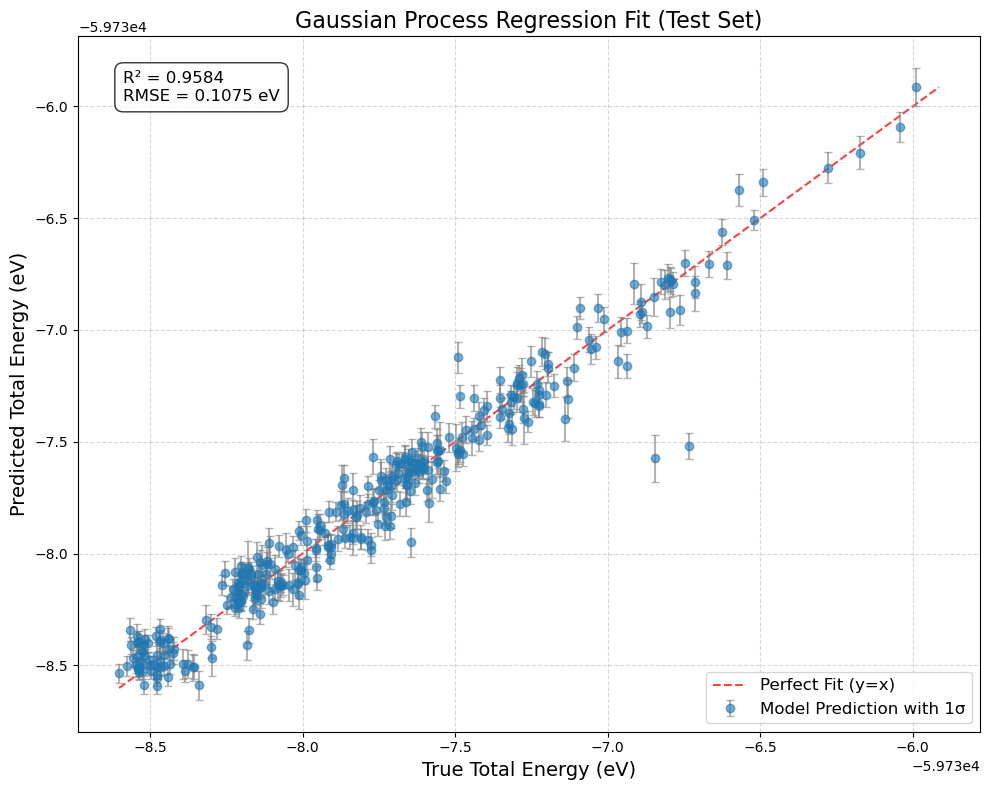

In [42]:

# Visualize predictions vs actual
plt.figure(figsize=(10, 8))

# Plot diagonal line
lims = [
    min(results['y_true'].min(), results['y_pred'].min()),
    max(results['y_true'].max(), results['y_pred'].max()),
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=1, label="Perfect Fit (y=x)")

# Scatter with error bars
plt.errorbar(
    results['y_true'], 
    results['y_pred'], 
    yerr=results['y_std'],
    fmt='o', 
    alpha=0.6, 
    ecolor='gray', 
    capsize=3,
    zorder=2,
    label="Model Prediction with 1σ"
)

plt.xlabel("True Total Energy (eV)", fontsize=14)
plt.ylabel("Predicted Total Energy (eV)", fontsize=14)
plt.title("Gaussian Process Regression Fit (Test Set)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Add metrics to plot
text_str = f"R² = {results['r2']:.4f}\nRMSE = {results['rmse']:.4f} eV"
plt.text(
    0.05, 0.95, text_str,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

## Generate Candidates

In [ ]:
from botorch.optim import optimize_acqf
import warnings

# Create acquisition function
base_acqf = UpperConfidenceBound(
    model=model,
    beta=CONFIG["acquisition"]["beta"],
    posterior_transform=ScalarizedPosteriorTransform(weights=torch.tensor([-1.0])),
    maximize=True
)

if CONFIG["acquisition"]["use_preference"]:
    pref_func = partial(
        compute_total_preference_fast,
        databank=databank,
        atom_ids=atoms,
        trace_target=CONFIG["acquisition"]["trace_target"],
        trace_sigma=CONFIG["acquisition"]["trace_sigma"],
        use_eigenvalue_preference=True,#CONFIG["acquisition"]["use_eigenvalue_preference"],
        eig_k=CONFIG["acquisition"]["eigenvalue_k"],
        supergaussian_index=CONFIG["acquisition"]["supergaussian_index"],
    )
    acqf = AnalyticCustomPreference(model=model, base_acqf=base_acqf,
                                     compute_preference_func=pref_func)
else:
    acqf = base_acqf

# acqf = base_acqf

# Generate candidates
print(f"\nGenerating {CONFIG['optimization']['num_candidates']} candidates...")

# Strategy: Generate multiple physics-informed initial guesses
num_physics_guesses = 10  # Generate 10 diverse starting points per candidate
num_restarts_actual = num_physics_guesses  # Match restarts to number of good guesses

print(f"Using {num_physics_guesses} physics-informed initial guesses with {num_restarts_actual} restarts per candidate\n")

candidates_list = []
acqf_values_list = []

for i in range(CONFIG['optimization']['num_candidates']):
    # Generate multiple diverse physics-informed initial guesses
    initial_guesses = []
    
    if CONFIG['optimization']['init_strategy'] == "best_train":
        # Use top-k training points
        sorted_idx = torch.argsort(y_train)
        for k in range(min(num_physics_guesses, len(y_train))):
            guess = x_train[sorted_idx[k]].unsqueeze(0).unsqueeze(0)
            initial_guesses.append(guess)
    
    elif CONFIG['optimization']['init_strategy'] == "patchwork":
        # Generate multiple patchwork combinations
        for _ in range(num_physics_guesses):
            guess = create_patchwork_guess(
                databank, x_train, atoms, DEVICE,
                # apply_rotation=CONFIG['optimization']['apply_rotation']
                apply_rotation=True
            )
            initial_guesses.append(guess)
    
    # Stack all guesses into batch [num_guesses, 1, num_features]
    if initial_guesses:
        batch_initial_conditions = torch.cat(initial_guesses, dim=0)
    else:
        batch_initial_conditions = None
    
    # Optimize with physics-informed restarts
    candidate_batch, acqf_value_batch = optimize_acqf(
        acq_function=acqf,
        bounds=bounds,
        q=1,
        num_restarts=num_restarts_actual,
        raw_samples=128,   
        batch_initial_conditions=batch_initial_conditions,
        return_best_only=False,
    )

    # The physics-informed constraints of the acquisition function are actually so tight
    # that basically no gradient update is made, this would be a good candidate for boltzmann sampling
    # or alternatively one should use the SO(N) representation for the symmetric matrices 

    best_acqf_idx = torch.argmax(acqf_value)
    candidate = candidate_batch[best_acqf_idx].unsqueeze(0)
    acqf_value = acqf_value_batch[best_acqf_idx]

    initial_acquisition_value = acqf(batch_initial_conditions[best_acqf_idx].unsqueeze(0)).item() if batch_initial_conditions is not None else float('nan')

    
    candidates_list.append(candidate)
    acqf_values_list.append(acqf_value.item())
    print(f"  Candidate {i+1}/{CONFIG['optimization']['num_candidates']}: acqf = {acqf_value.item():.8f} from initial acqf = {initial_acquisition_value:.8f}")

candidates = torch.cat(candidates_list, dim=0)
print(f"\n✓ Generated {len(candidates_list)} candidates")


Generating 10 candidates...
Using 10 physics-informed initial guesses with 10 restarts per candidate



/home/carta_a/anaconda3/lib/python3.12/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL_TERMINATION_IN_LNSRCH.')]
Because you specified `batch_initial_conditions` larger than required `num_restarts`, optimization will not be retried with new initial conditions and will proceed with the current solution. Suggested remediation: Try again with different `batch_initial_conditions`, don't provide `batch_initial_conditions`, or increase `num_restarts`.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


  Candidate 1/10: acqf = 59735.79687500 from initial acqf = 59735.79687500
  Candidate 2/10: acqf = 59736.57812500 from initial acqf = 59736.57812500


/home/carta_a/anaconda3/lib/python3.12/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL_TERMINATION_IN_LNSRCH.')]
Because you specified `batch_initial_conditions` larger than required `num_restarts`, optimization will not be retried with new initial conditions and will proceed with the current solution. Suggested remediation: Try again with different `batch_initial_conditions`, don't provide `batch_initial_conditions`, or increase `num_restarts`.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


  Candidate 3/10: acqf = 59736.78906250 from initial acqf = 59736.78906250
  Candidate 4/10: acqf = 59737.56640625 from initial acqf = 59737.56640625


...

/home/carta_a/anaconda3/lib/python3.12/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL_TERMINATION_IN_LNSRCH.')]
Because you specified `batch_initial_conditions` larger than required `num_restarts`, optimization will not be retried with new initial conditions and will proceed with the current solution. Suggested remediation: Try again with different `batch_initial_conditions`, don't provide `batch_initial_conditions`, or increase `num_restarts`.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


  Candidate 8/10: acqf = 59735.35937500 from initial acqf = 59735.35937500


/home/carta_a/anaconda3/lib/python3.12/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL_TERMINATION_IN_LNSRCH.')]
Because you specified `batch_initial_conditions` larger than required `num_restarts`, optimization will not be retried with new initial conditions and will proceed with the current solution. Suggested remediation: Try again with different `batch_initial_conditions`, don't provide `batch_initial_conditions`, or increase `num_restarts`.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


  Candidate 9/10: acqf = 59735.56250000 from initial acqf = 59735.56250000
  Candidate 10/10: acqf = 59736.80468750 from initial acqf = 59736.80468750

✓ Generated 10 candidates


/home/carta_a/anaconda3/lib/python3.12/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL_TERMINATION_IN_LNSRCH.'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL_TERMINATION_IN_LNSRCH.'), OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL_TERMINATION_IN_LNSRCH.')]
Because you specified `batch_initial_conditions` larger than required `num_restarts`, optimization will not be retried with new initial conditions and will proceed with the current solution. Suggested remediation: Try again with different `batch_initial_conditions`, don't provide `batch_initial_conditions`, or increase `num_restarts`.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


In [56]:
# test acquisition on initial guess
from importlib import reload
import lordcapulet.functions.proposal_modes.Bayesian.acquisition as acquisition

reload(acquisition)



result_cpu = acquisition.compute_total_preference_fast(
    candidates[0],
    databank=databank,
    atom_ids=atoms,
    trace_target=CONFIG["acquisition"]["trace_target"],
    trace_sigma=CONFIG["acquisition"]["trace_sigma"],
    use_eigenvalue_preference=CONFIG["acquisition"]["use_eigenvalue_preference"],
    eig_k=CONFIG["acquisition"]["eigenvalue_k"]
)

print(f"Preference score (CPU): {result_cpu}")


Preference score (CPU): tensor([1.], device='cuda:0')


## Summary of Candidates

In [57]:
# Summary table
print("\n" + "="*80)
print("CANDIDATE SUMMARY")
print("="*80)
print(f"{'#':<4} {'Acqf':<12} {'Energy (eV)':<20} {'Uncertainty':<12}")
print("-"*80)

with torch.no_grad():
    for i, (cand, acqf_val) in enumerate(zip(candidates_list, acqf_values_list)):
        posterior = model.posterior(cand)
        mean_energy = posterior.mean.item()
        std_energy = posterior.variance.sqrt().item()
        print(f"{i+1:<4} {acqf_val:<12.4f} {mean_energy:<12.4f} ± {std_energy:<12.4f}")

print("="*80)
best_idx = np.argmax(acqf_values_list)
print(f"Best acquisition: Candidate {best_idx + 1}")


CANDIDATE SUMMARY
#    Acqf         Energy (eV)          Uncertainty 
--------------------------------------------------------------------------------
1    59735.7969   -59735.6289  ± 0.1672      
2    59736.5781   -59736.3945  ± 0.1833      
3    59736.7891   -59736.5898  ± 0.1996      
4    59737.5664   -59737.3594  ± 0.2065      
5    59736.7930   -59736.6250  ± 0.1663      
6    59735.8477   -59735.6562  ± 0.1896      
7    59736.1289   -59735.9492  ± 0.1816      
8    59735.3594   -59735.1797  ± 0.1791      
9    59735.5625   -59735.2656  ± 0.2963      
10   59736.8047   -59736.6250  ± 0.1778      
Best acquisition: Candidate 4


## Analyze Specific Candidate


=== Candidate 4 ===
Acquisition: 59737.5664
Energy: -59737.3594 ± 0.2065 eV
Minor Preference Multiplier (up) for 1: 1.0000
Minor Preference Multiplier (down) for 1: 1.0000

1:
  Trace: 2.669
  Eigenvalues (up): [0.031 0.038 0.044 0.044 0.047 0.05  0.093]
  Eigenvalues (down): [0.053 0.055 0.057 0.06  0.295 0.823 0.979]


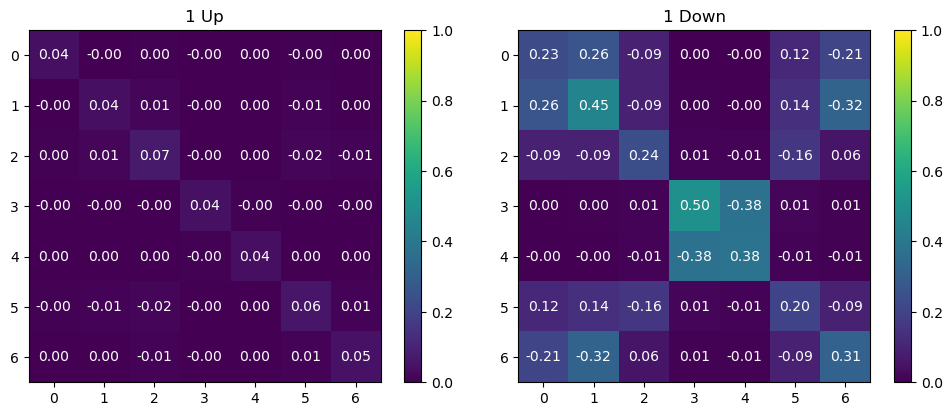

Minor Preference Multiplier (up) for 2: 1.0000
Minor Preference Multiplier (down) for 2: 1.0000

2:
  Trace: 2.644
  Eigenvalues (up): [0.041 0.046 0.053 0.059 0.138 0.974 0.979]
  Eigenvalues (down): [0.032 0.035 0.036 0.041 0.044 0.052 0.112]


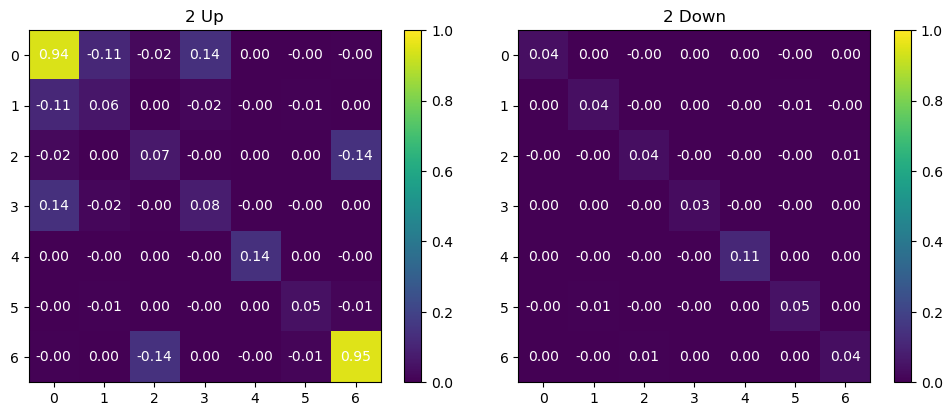

Minor Preference Multiplier (up) for 3: 1.0000
Minor Preference Multiplier (down) for 3: 1.0000

3:
  Trace: 2.673
  Eigenvalues (up): [0.031 0.032 0.034 0.039 0.042 0.059 0.108]
  Eigenvalues (down): [0.052 0.061 0.116 0.148 0.211 0.823 0.918]


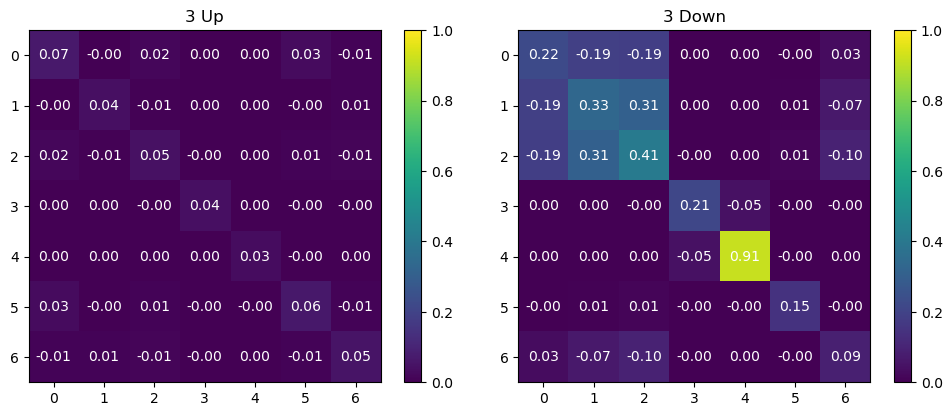

Minor Preference Multiplier (up) for 4: 1.0000
Minor Preference Multiplier (down) for 4: 1.0000

4:
  Trace: 2.653
  Eigenvalues (up): [0.041 0.05  0.078 0.131 0.169 0.866 0.966]
  Eigenvalues (down): [0.034 0.036 0.037 0.041 0.045 0.061 0.097]


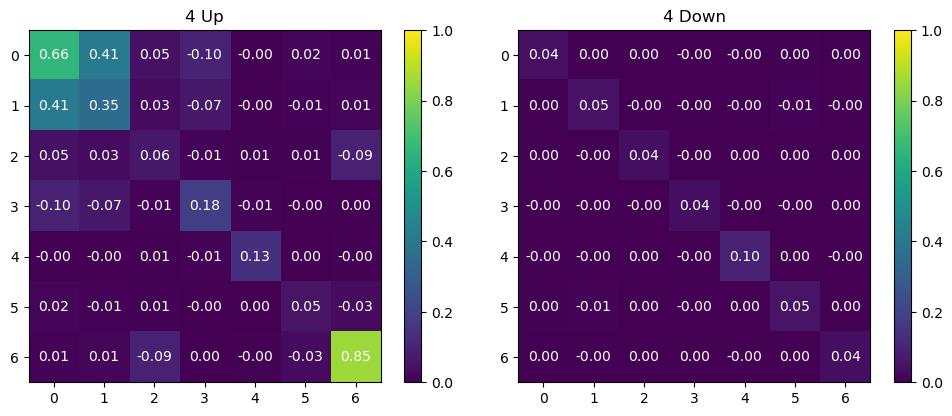

In [58]:
# Select candidate to analyze
CANDIDATE_INDEX = best_idx  # Change this to analyze different candidates

candidate = candidates_list[CANDIDATE_INDEX]
matrices_candidate = databank.from_pytorch(
    candidate[0].detach(), 
    atom_ids=atoms, 
    spins=['up', 'down']
)[0]

print(f"\n=== Candidate {CANDIDATE_INDEX + 1} ===")
print(f"Acquisition: {acqf_values_list[CANDIDATE_INDEX]:.4f}")

# compute minor multiplier for this candidate

from acquisition import compute_minor_preference_offdiag_only



with torch.no_grad():
    posterior = model.posterior(candidate)
    print(f"Energy: {posterior.mean.item():.4f} ± {posterior.variance.sqrt().item():.4f} eV")

# Display occupation matrices
for atom_id in atoms:
    up_mat = np.array(matrices_candidate.get_occupation_matrix(atom_id, 'up'))
    down_mat = np.array(matrices_candidate.get_occupation_matrix(atom_id, 'down'))

    minor_pref_up = compute_minor_preference_offdiag_only(torch.tensor(up_mat), CONFIG["acquisition"]["eigenvalue_k"])
    minor_pref_down = compute_minor_preference_offdiag_only(torch.tensor(down_mat), CONFIG["acquisition"]["eigenvalue_k"])

    print(f"Minor Preference Multiplier (up) for {atom_id}: {minor_pref_up:.4f}")
    print(f"Minor Preference Multiplier (down) for {atom_id}: {minor_pref_down:.4f}")
    
    print(f"\n{atom_id}:")
    print(f"  Trace: {np.trace(up_mat) + np.trace(down_mat):.3f}")
    print(f"  Eigenvalues (up): {np.round(np.linalg.eigvalsh(up_mat), 3)}")
    print(f"  Eigenvalues (down): {np.round(np.linalg.eigvalsh(down_mat), 3)}")
    
    # Visualize
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    
    for idx, (mat, title) in enumerate([(up_mat, 'Up'), (down_mat, 'Down')]):
        im = axs[idx].imshow(np.abs(mat), cmap='viridis', vmin=0, vmax=1)
        axs[idx].set_title(f'{atom_id} {title}')
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                axs[idx].text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center', color='w')
        fig.colorbar(im, ax=axs[idx])
    
    plt.tight_layout()
    plt.show()

## Novelty Analysis


Novelty Metrics:
  Min distance to training: 2.826246
  Mean distance: 3.355288
  Median distance: 3.368852


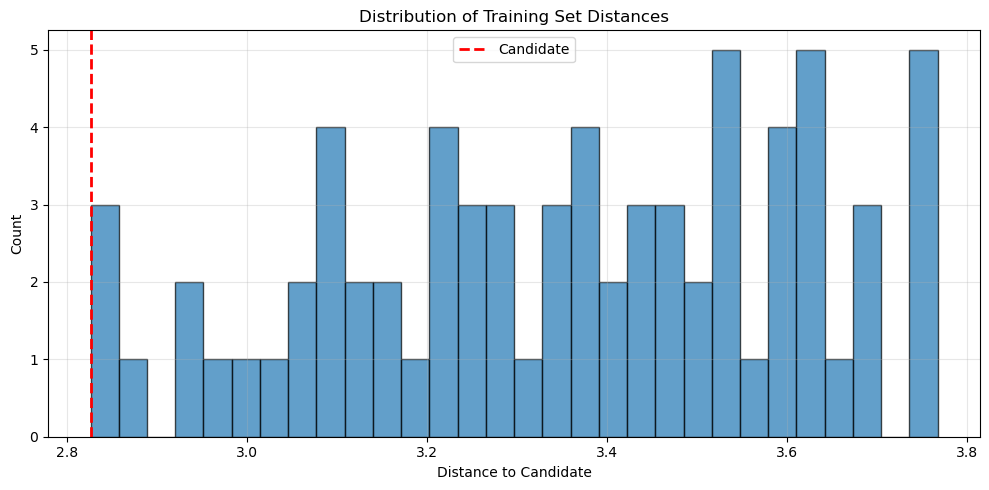

In [10]:
# Compute distances to training set
train_indices = perm[:num_train].cpu().numpy()
train_databank = databank[train_indices]

distances = train_databank.compute_distances(
    reference=matrices_candidate,
    atom_label=None,
    spins=['up', 'down']
)

print(f"\nNovelty Metrics:")
print(f"  Min distance to training: {distances.min():.6f}")
print(f"  Mean distance: {distances.mean():.6f}")
print(f"  Median distance: {np.median(distances):.6f}")

# Visualize
plt.figure(figsize=(10, 5))
plt.hist(distances, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(distances.min(), color='red', linestyle='--', linewidth=2, label='Candidate')
plt.xlabel("Distance to Candidate")
plt.ylabel("Count")
plt.title("Distribution of Training Set Distances")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Optional: Model Diagnostics

In [ ]:
# Prediction vs actual plot
plt.figure(figsize=(8, 8))
lims = [min(results['y_true'].min(), results['y_pred'].min()),
        max(results['y_true'].max(), results['y_pred'].max())]
plt.plot(lims, lims, 'r--', alpha=0.75, label="Perfect Fit")
plt.errorbar(results['y_true'], results['y_pred'], yerr=results['y_std'],
             fmt='o', alpha=0.6, ecolor='gray', capsize=3, label="Predictions")
plt.xlabel("True Energy (eV)")
plt.ylabel("Predicted Energy (eV)")
plt.title(f"GP Model Performance (R²={results['r2']:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Kernel diagnostics
from gp_model import print_kernel_diagnostics
print_kernel_diagnostics(model)

## Export Candidates

Convert candidates to OccupationMatrixData format for use with AiiDA workflows.

In [ ]:
# Convert all candidates to OccupationMatrixData
candidate_proposals = []
for i, cand in enumerate(candidates_list):
    occ_data = databank.from_pytorch(
        cand[0].detach().unsqueeze(0),
        atom_ids=atoms,
        spins=['up', 'down']
    )[0]
    candidate_proposals.append(occ_data)

print(f"\nExported {len(candidate_proposals)} candidates as OccupationMatrixData objects")
print("Ready for use with AiiDA workflows")